# Intersectional Subgroups — Beyond Single-Attribute Fairness Audits

`Compas Analysis.ipynb` (the original ProPublica notebook in this repository) audits COMPAS's false positive rate by **race alone**. This notebook asks the question a single-attribute audit can't answer: what happens to that audit once you condition on **race and sex together**?

This matters for two distinct reasons, both visible in the numbers below:

1. **Aggregation can hide real disparities.** A group that looks fine on average can contain subgroups that don't — or vice versa. Auditing only by race, or only by sex, can miss a pattern that only appears at the intersection.
2. **Intersecting attributes shrinks sample sizes fast.** Six race categories × two sex categories gives twelve cells, several of which will contain a handful of people. A fairness metric computed on 6 people is not the same kind of evidence as one computed on 1,500 — and reporting both as a single point estimate without saying so is itself a way of misleading an audience.

We reuse the exact same filtered dataset as the main notebook, so every number here is directly comparable to it.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportion_confint

## Load and filter data

Identical filtering criteria to `Compas Analysis.ipynb`: screening within 30 days of arrest, a resolved recidivism outcome, no ordinary-traffic charges, and a valid risk category. This should reproduce the same 6,172-row cohort the main notebook analyses.

In [2]:
df = pd.read_csv("compas-scores-two-years.csv")

df = df[
    (df.days_b_screening_arrest <= 30)
    & (df.days_b_screening_arrest >= -30)
    & (df.is_recid != -1)
    & (df.c_charge_degree != "O")
    & (df.score_text != "N/A")
].copy()

print(f"Cohort size: {len(df)}")

df["predicted_high_risk"] = df.score_text.isin(["Medium", "High"]).astype(int)
df["reoffended"] = df.two_year_recid

Cohort size: 6172


## The metric: false positive rate

Following the main notebook's headline finding, we use **false positive rate (FPR)**: among people who did *not* reoffend within two years, what fraction did COMPAS flag as Medium/High risk anyway? This is the metric behind ProPublica's central claim — that COMPAS flags Black defendants who won't reoffend at roughly twice the rate it flags White defendants who won't reoffend.

We report a [Wilson score confidence interval](https://en.wikipedia.org/wiki/Binomial_proportion_confidence_interval#Wilson_score_interval) alongside every point estimate — the standard interval for a proportion, and one that stays sensible (doesn't go below 0% or above 100%) even for very small samples, unlike the naive normal-approximation interval.

In [3]:
def fpr_with_ci(group):
    no_reoffend = group[group.reoffended == 0]
    n = len(no_reoffend)
    if n == 0:
        return pd.Series({"n_no_reoffend": 0, "fpr": np.nan, "ci_low": np.nan, "ci_high": np.nan})
    false_positives = no_reoffend.predicted_high_risk.sum()
    fpr = false_positives / n
    lo, hi = proportion_confint(false_positives, n, method="wilson")
    return pd.Series({"n_no_reoffend": n, "fpr": fpr, "ci_low": lo, "ci_high": hi})

## FPR by race alone (replicating the known result)

In [4]:
by_race = df.groupby("race", observed=True).apply(fpr_with_ci, include_groups=False).round(3)
by_race = by_race.sort_values("fpr", ascending=False)
by_race

,n_no_reoffend,fpr,ci_low,ci_high
race,,,,
Native American,6.0,0.500,0.188,0.812
African-American,1514.0,0.423,0.399,0.448
Caucasian,1281.0,0.220,0.198,0.244
Hispanic,320.0,0.194,0.154,0.241
Other,219.0,0.128,0.090,0.179
Asian,23.0,0.087,0.024,0.268


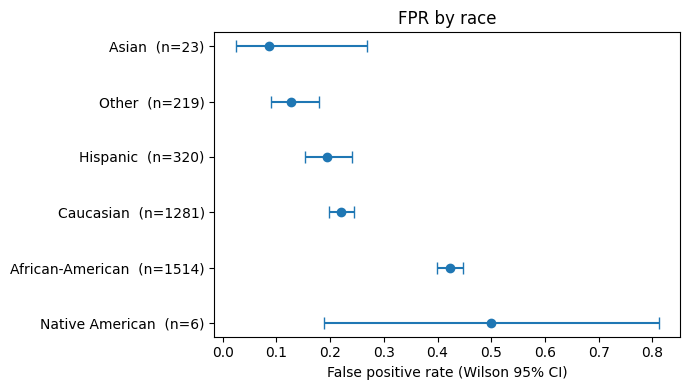

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
order = by_race.index
y = np.arange(len(order))
ax.errorbar(
    by_race.loc[order, "fpr"], y,
    xerr=[by_race.loc[order, "fpr"] - by_race.loc[order, "ci_low"],
          by_race.loc[order, "ci_high"] - by_race.loc[order, "fpr"]],
    fmt="o", capsize=4,
)
ax.set_yticks(y)
ax.set_yticklabels([f"{r}  (n={int(by_race.loc[r,'n_no_reoffend'])})" for r in order])
ax.set_xlabel("False positive rate (Wilson 95% CI)")
ax.set_title("FPR by race")
fig.tight_layout()
fig.show()

Black defendants who did not reoffend were flagged as high-risk at roughly twice the rate of White defendants who did not reoffend, and the confidence intervals for the two largest groups don't overlap — this is a well-supported disparity, not noise.

## Now intersect with sex

In [6]:
by_race_sex = df.groupby(["race", "sex"], observed=True).apply(fpr_with_ci, include_groups=False).round(3)
by_race_sex

n_no_reoffend    fpr  ci_low  ci_high
race             sex                                          
African-American Female          346.0  0.379   0.329    0.431
                 Male           1168.0  0.437   0.408    0.465
Asian            Female            1.0  0.000   0.000    0.793
                 Male             22.0  0.091   0.025    0.278
Caucasian        Female          312.0  0.288   0.241    0.341
                 Male            969.0  0.198   0.174    0.224
Hispanic         Female           56.0  0.054   0.018    0.146
                 Male            264.0  0.223   0.177    0.277
Native American  Female            0.0    NaN     NaN      NaN
                 Male              6.0  0.500   0.188    0.812
Other            Female           47.0  0.128   0.060    0.252
                 Male            172.0  0.128   0.086    0.186

Two things should jump out immediately.

**Some cells can't support a metric at all.** There are zero non-reoffending Native American women in this cohort (`n_no_reoffend = 0`) — FPR is undefined, not zero. There is exactly one non-reoffending Asian woman, whose FPR is reported as a clean `0.000` — a number that looks precise but rests on a single person, with a confidence interval spanning from 0% to 79%. Native American men fare little better (n=6, CI roughly 19%–81%: the data are consistent with almost any true rate). Reporting these point estimates without their intervals — as a plain groupby table without the CI columns would do — presents manufactured precision as real precision.

**Some cells reveal a pattern the race-only view hides.** Compare Caucasian women (FPR ≈ 0.29, 95% CI roughly 0.24–0.34) against Caucasian men (FPR ≈ 0.20, CI roughly 0.17–0.22): the intervals don't overlap. The race-only aggregate (≈0.22) sits between them and represents neither group well. The same pattern, in the opposite direction, appears for Hispanic defendants: women's FPR (≈0.05, CI 0.02–0.15) sits well below men's (≈0.22, CI 0.18–0.28) — again non-overlapping, and again invisible if you only ever condition on race or only ever condition on sex.

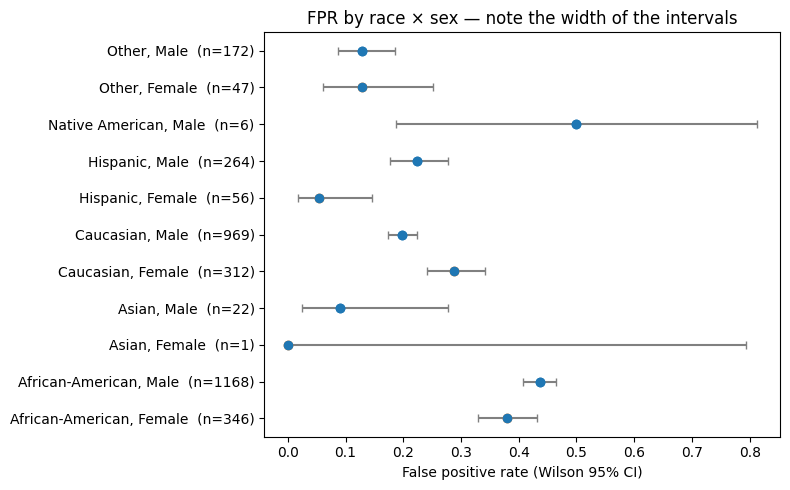

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_rows = by_race_sex.dropna(subset=["fpr"])
y = np.arange(len(plot_rows))
colors = ["tab:blue" if s == "Male" else "tab:orange" for _, s in plot_rows.index]
ax.errorbar(
    plot_rows["fpr"], y,
    xerr=[plot_rows["fpr"] - plot_rows["ci_low"], plot_rows["ci_high"] - plot_rows["fpr"]],
    fmt="o", capsize=3, ecolor="gray",
)
for yi, c in zip(y, colors):
    ax.plot(plot_rows["fpr"].iloc[yi], yi, "o", color=c)
ax.set_yticks(y)
ax.set_yticklabels([f"{r}, {s}  (n={int(n)})" for (r, s), n in zip(plot_rows.index, plot_rows.n_no_reoffend)])
ax.set_xlabel("False positive rate (Wilson 95% CI)")
ax.set_title("FPR by race × sex — note the width of the intervals")
fig.tight_layout()
fig.show()

## Discussion

**Why not just report every intersectional cell and let readers judge?** Because a wide confidence interval is easy to skim past in a table, and a bar chart without error bars presents every estimate as equally trustworthy. The Native American, n=6 bar looks exactly as confident as the Black, n=1,514 bar unless you draw the interval.

**How do practitioners actually handle this in the field?** A few common approaches, each with a real cost:

- **Partial pooling / hierarchical shrinkage.** Instead of estimating each intersectional cell independently, shrink small cells toward the race-only (or population) estimate, weighted by how much data each cell has. This gives every group a number, but a shrunk one — it trades away some of the very specificity that motivated the intersectional analysis.
- **Explicit suppression.** Refuse to report a metric below a minimum sample size, and say so. Honest, but it means the smallest, often most marginalised groups are the ones a fairness audit says the least about.
- **Aggregating over a longer time window or wider population** to get workable sample sizes — at the cost of currency and of mixing potentially different underlying conditions.

**Discussion questions for students:**

1. Pick one small intersectional cell above. If you were advising a court or a vendor, would you report its point estimate, suppress it, or shrink it toward the race-only estimate? Justify your choice.
2. The Caucasian and Hispanic sex-splits above are real, non-overlapping disparities that the race-only audit misses entirely. Can you think of a mechanism (screening practices, base rates, something else in the dataset) that might explain *why* sex interacts with race here specifically for these two groups?
3. This notebook only intersects two attributes. What happens to sample sizes, and to your ability to say anything statistically meaningful, if you added a third (e.g. age category)? At what point does an intersectional audit become uninformative purely because of sample size, regardless of how real the underlying disparity might be?